

**Importing all the required libraries**

In [1]:
# Importing the libraries
import os
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
from keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import zipfile

2025-10-04 19:47:41.842772: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-04 19:47:41.842912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-04 19:47:41.973213: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# !unzip /content/archive.zip
# For Google Colab Execution

In [3]:
# Some functions to help out with
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real PWR')
    plt.plot(predicted, color='green',label='Predicted PWR')
    plt.title('Demand Prediction')
    plt.xlabel('Time')
    plt.ylabel('Prediction')
    plt.title("GRU Model 1 Day Prediction")
    plt.legend()
    plt.show()

# Calculation of Root Mean Squared-Error
def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Calculation of Mean Absolute Error
def return_mae(test,predicted):
    rmse = math.sqrt(mean_absolute_error(test, predicted))
    print("The mean absolute error is {}.".format(rmse))

# Calculation of R2 Score
def return_r2(test,predicted):
    rmse = math.sqrt(r2_score(test, predicted))
    print("The r2 score is {}.".format(rmse))

In [4]:
df=pd.read_excel('/kaggle/input/lf-data/__2324.xlsx')

In [5]:
# # Ensure Date N Time column is datetime
# df['Date N Time'] = pd.to_datetime(df['Date N Time'])

# # Create a week identifier (Year-Week)
# df['YearWeek'] = df['Date N Time'].dt.to_period('W')

# # Replace zeros with weekly mean (ignoring zeros)
# for col in df.select_dtypes(include=['int64', 'float64']).columns:
#     df[col] = df.groupby('YearWeek')[col].transform(
#         lambda x: x.replace(0, x[x != 0].mean())
#     )

# # Drop helper column if not needed
# df.drop(columns=['YearWeek'], inplace=True)

# # Replace NaNs with zeros
# df.fillna(0, inplace=True)


In [6]:
# df.reset_index(inplace=True, drop=True)
# df['Date N Time'] = pd.to_datetime(df['Date N Time'], dayfirst=True, errors='coerce')

In [7]:
df['Date N Time'] = pd.to_datetime(df['Date N Time'])

In [8]:
df.set_index('Date N Time', inplace=True)

In [9]:
print(type(df.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [10]:
df.columns

Index(['M1_PWR', 'M2_PWR', 'M3_PWR'], dtype='object')

In [11]:
df = df.sort_values(by='Date N Time')

In [12]:
df.shape

(184560, 3)

In [13]:
df.columns

Index(['M1_PWR', 'M2_PWR', 'M3_PWR'], dtype='object')

In [14]:
df.describe()

,M1_PWR,M2_PWR,M3_PWR
count,184560.000000,184560.000000,184560.000000
mean,-80.583934,-80.634833,-80.515800
std,92.393289,92.426647,92.280570
min,-368.607178,-368.465271,-358.871857
25%,-163.929127,-163.988728,-163.740891
50%,-96.879768,-96.847389,-96.737259
75%,0.000000,0.000000,0.000000
max,188.991653,188.900467,188.037827


In [15]:
df_refined=df['M3_PWR'].resample('6min').mean()

In [16]:
df_refined.isnull().sum()

6121

In [17]:
df_refined.describe()

count    169680.000000
mean        -81.210210
std          92.346026
min        -358.871857
25%        -164.292671
50%         -99.142666
75%           0.000000
max         188.037827
Name: M3_PWR, dtype: float64

In [18]:
df_refined[0:10]

Date N Time
2022-12-30 17:24:00      0.000000
2022-12-30 17:30:00      0.000000
2022-12-30 17:36:00     67.461899
2022-12-30 17:42:00     97.816338
2022-12-30 17:48:00   -146.325882
2022-12-30 17:54:00   -231.510635
2022-12-30 18:00:00   -225.152557
2022-12-30 18:06:00   -223.958832
2022-12-30 18:12:00   -228.615356
2022-12-30 18:18:00   -221.402832
Freq: 6min, Name: M3_PWR, dtype: float64

In [19]:
# df['M1_PWR_CLEANED'] = df['M1_PWR'].replace(0, np.nan)

In [20]:
df_refined.fillna(0, inplace=True)

In [21]:
df_refined[236:244]

Date N Time
2022-12-31 17:00:00   -131.808502
2022-12-31 17:06:00   -135.090988
2022-12-31 17:12:00   -139.301758
2022-12-31 17:18:00   -136.907806
2022-12-31 17:24:00      0.000000
2022-12-31 17:30:00      0.000000
2022-12-31 17:36:00      0.000000
2022-12-31 17:42:00      0.000000
Freq: 6min, Name: M3_PWR, dtype: float64

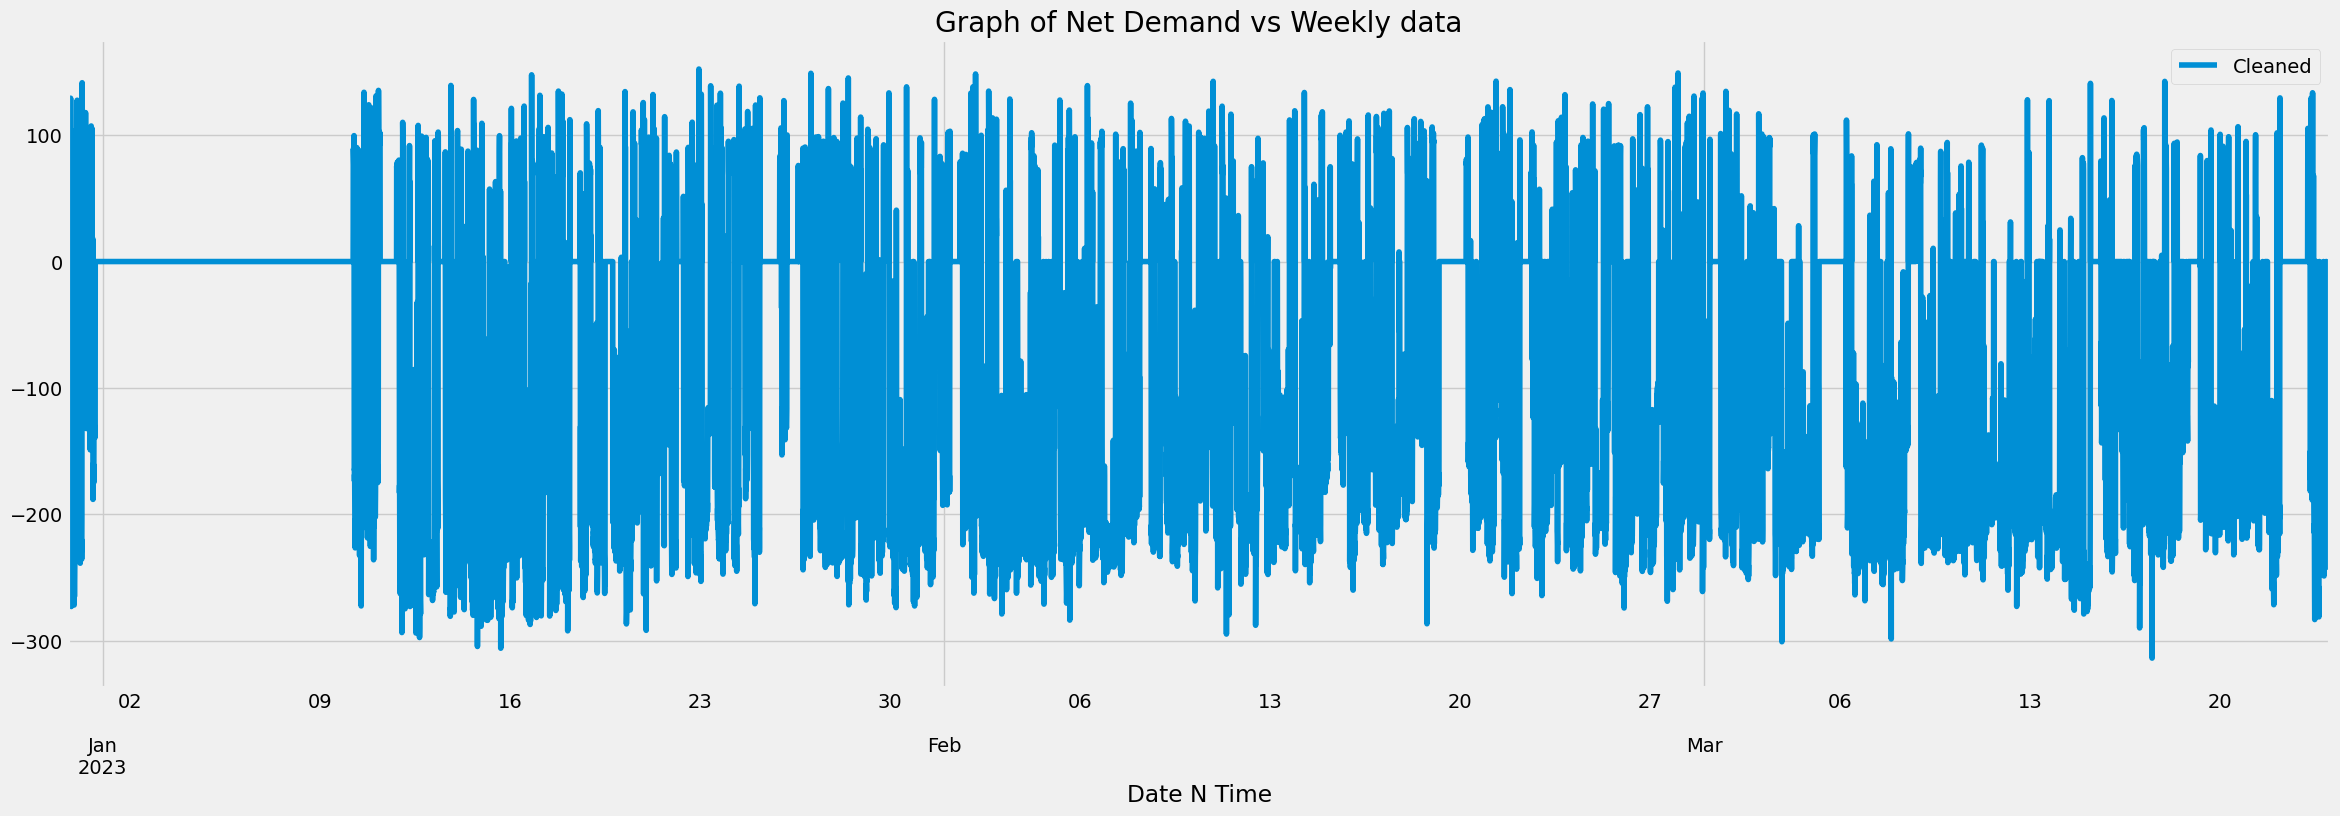

In [22]:
# df['M1_PWR_CLEANED'][0:1000].plot(figsize=(26,8),legend=True)
df_refined[0:20000].plot(figsize=(26,8),legend=True)
plt.legend(['Cleaned','As it is'])
plt.title('Graph of Net Demand vs Weekly data')
plt.show()

Here, we are trying to check the overall trend of the nat_demand

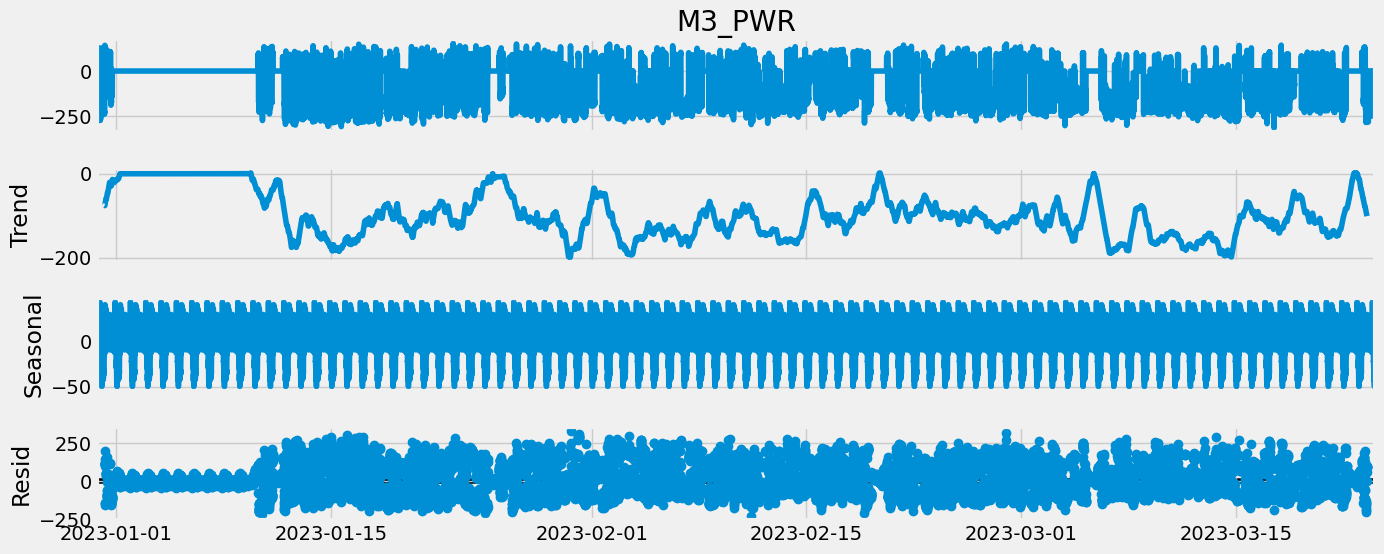

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(df_refined[0:20000], model='additive', period=240)
fig = decomp.plot()
fig.set_figheight(6)
fig.set_figwidth(16)

In [24]:
# Checking for missing values
training_set = df_refined.values
training_set=training_set.reshape((training_set.shape[0],1))

In [25]:
print("Training Set Shape : ",training_set.shape)

Training Set Shape :  (175801, 1)


In [26]:
training_set[0]

array([0.])

In [37]:
X=training_set;

In [38]:
training_set

array([[   0.        ],
       [   0.        ],
       [  67.4618988 ],
       ...,
       [-165.12992859],
       [-172.17163086],
       [ -50.78382111]])

In [39]:
training_set.sum()

-13779748.508438557

In [40]:
#X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
#training_set_scaled = X_std * (2) - 1

**Scaling the training set from values 0 to 1**

In [41]:
sc = MinMaxScaler(feature_range=(-1,1))
training_set_scaled = sc.fit_transform(training_set)

In [42]:
training_set_scaled.shape

(175801, 1)

In [43]:
(training_set_scaled>=0).sum()

87915

In [44]:
(training_set_scaled<=0).sum()

87886

In [45]:
training_set_scaled

array([[ 0.31236242],
       [ 0.31236242],
       [ 0.55906457],
       ...,
       [-0.29150302],
       [-0.3172539 ],
       [ 0.12665051]])

In [46]:
X_train = []
Y_train = []

input_steps = 1000 # 10 hours of history
output_steps = 1   # Next 60 minutes

for i in range(input_steps, len(training_set_scaled) - output_steps):
    X_train.append(training_set_scaled[i-input_steps:i, 0])
    Y_train.append(training_set_scaled[i:i+output_steps, 0])

X_train, Y_train = np.array(X_train), np.array(Y_train)

# Reshape for LSTM/GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [47]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [48]:
X_train.shape

(174800, 1000, 1)

In [49]:
Y_train.shape

(174800, 1)

In [50]:
# X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
# Y_train = np.nan_to_num(Y_train, nan=0.0, posinf=0.0, neginf=0.0)

In [51]:
import numpy as np

print("X_train NaNs:", np.isnan(X_train).sum())
print("X_train Infs:", np.isinf(X_train).sum())
print("y_train NaNs:", np.isnan(Y_train).sum())
print("y_train Infs:", np.isinf(Y_train).sum())

X_train NaNs: 0
X_train Infs: 0
y_train NaNs: 0
y_train Infs: 0


**Our GRU Model**

In [52]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',       # You can also monitor 'val_mae' or 'val_r2_score'
    patience=5,               # Stop after 5 epochs with no improvement
    restore_best_weights=True # Roll back to the best weights
)


In [53]:
EPOCHS=5

from keras.models import Sequential
from keras.layers import GRU, LSTM, Dense, Dropout

model = Sequential()
model.add(GRU(128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(GRU(64, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1000, 128)      │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,617 (342.25 KB)

 Trainable params: 87,617 (342.25 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.fit(X_train,Y_train, epochs=EPOCHS,batch_size=64, shuffle=False)

Epoch 1/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 254s 92ms/step - loss: 0.0266
Epoch 2/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 250s 92ms/step - loss: 0.0230
Epoch 3/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 251s 92ms/step - loss: 0.0223
Epoch 4/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 250s 92ms/step - loss: 0.0219
Epoch 5/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 251s 92ms/step - loss: 0.0216


In [55]:
model.save('/kaggle/working/GRU_LF_Model3.h5')

**Testing Part**

In [56]:
df2=pd.read_excel('/kaggle/input/lf-data/Random_25.xlsx')

In [57]:
df2['Date N Time'] = pd.to_datetime(df2['Date N Time'])

In [58]:
df2.set_index('Date N Time', inplace=True)

In [59]:
df2.index = pd.to_datetime(df2.index)

In [60]:
df2 = pd.concat([df[-1000:], df2])

In [61]:
df2 = df2.sort_values(by='Date N Time')

In [62]:
df_refined2=df2['M1_PWR'].resample('6min').mean()

In [63]:
df_refined2

Date N Time
2024-12-28 01:30:00   -141.692093
2024-12-28 01:36:00   -176.474075
2024-12-28 01:42:00   -161.600632
2024-12-28 01:48:00   -169.355347
2024-12-28 01:54:00   -176.420441
                          ...    
2025-01-04 05:00:00   -184.231461
2025-01-04 05:06:00   -203.618546
2025-01-04 05:12:00   -189.858643
2025-01-04 05:18:00   -186.063309
2025-01-04 05:24:00   -181.041611
Freq: 6min, Name: M1_PWR, Length: 1720, dtype: float64

In [64]:
# df.shape

In [65]:
df_refined2.isnull().sum()

480

In [66]:
df_refined2.fillna(0, inplace=True)

In [67]:
df_refined2

Date N Time
2024-12-28 01:30:00   -141.692093
2024-12-28 01:36:00   -176.474075
2024-12-28 01:42:00   -161.600632
2024-12-28 01:48:00   -169.355347
2024-12-28 01:54:00   -176.420441
                          ...    
2025-01-04 05:00:00   -184.231461
2025-01-04 05:06:00   -203.618546
2025-01-04 05:12:00   -189.858643
2025-01-04 05:18:00   -186.063309
2025-01-04 05:24:00   -181.041611
Freq: 6min, Name: M1_PWR, Length: 1720, dtype: float64

In [68]:
# Checking for missing values
test_set = df_refined2.values
test_set=test_set.reshape((test_set.shape[0],1))

In [69]:
test_set.shape

(1720, 1)

In [70]:
# test_set = np.nan_to_num(test_set, nan=0.0, posinf=0.0, neginf=0.0)

In [71]:
sc = MinMaxScaler(feature_range=(-1,1))
test_set_scaled = sc.fit_transform(test_set)

In [72]:
# X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))

In [73]:
inputs=test_set_scaled
X_test = []
for i in range(1000,len(inputs)):
    X_test.append(inputs[i-1000:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_data = model.predict(X_test)
predicted_data = sc.inverse_transform(predicted_data)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


In [74]:
# test_set2=test_set[600:len(inputs)]

In [75]:
test_set2=test_set[-240::]
predicted_data2=predicted_data[-240::]

In [76]:
(predicted_data<1).sum()

715

In [77]:
(predicted_data>1).sum()

5

In [78]:
test_set2.shape

(240, 1)

In [79]:
predicted_data2.shape

(240, 1)

**Actual Demand vs Predicted Demand**

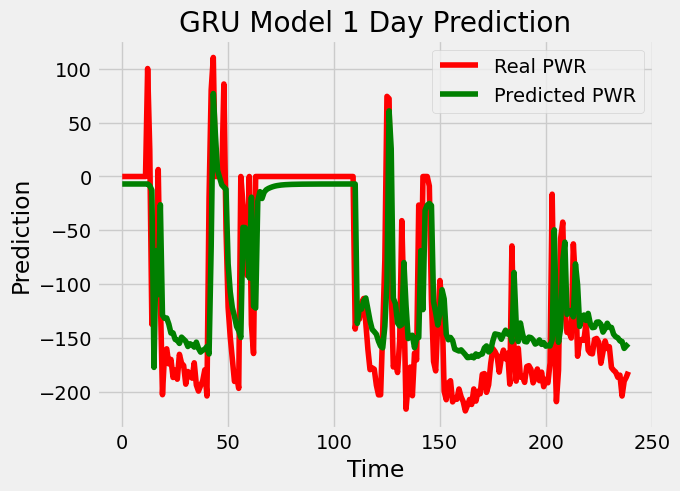

In [80]:
plot_predictions(test_set2,predicted_data2)

In [81]:
return_rmse(test_set2,predicted_data2)

The root mean squared error is 48.04014909394297.


In [82]:
return_mae(test_set2,predicted_data2)

The mean absolute error is 5.921307107566344.


In [83]:
errors = np.abs(test_set2 - predicted_data2)
print("Max error:", errors.max())
print("Mean error:", errors.mean())


Max error: 172.3833465576172
Mean error: 35.0618778621157


In [84]:
from sklearn.metrics import r2_score

r2 = r2_score(test_set2, predicted_data2)
print(f"R² Score: {r2:.4f}")

R² Score: 0.6989


In [85]:
import numpy as np

def accuracy_within_tolerance(y_true, y_pred, tolerance=0.05):
    """
    Calculates the percentage of predictions within a given percentage tolerance.
    
    Parameters:
        y_true (array-like): Actual values
        y_pred (array-like): Predicted values
        tolerance (float): Acceptable percentage error (e.g., 0.05 for 5%)

    Returns:
        accuracy (float): Accuracy as a percentage
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # Avoid division by zero
    nonzero_indices = y_true != 0
    y_true = y_true[nonzero_indices]
    y_pred = y_pred[nonzero_indices]

    relative_errors = np.abs((y_pred - y_true) / y_true)
    within_tolerance = relative_errors <= tolerance
    accuracy = np.mean(within_tolerance) * 100

    print(f"Accuracy within ±{tolerance * 100:.1f}%: {accuracy:.2f}%")
    return accuracy


In [86]:
# Suppose you have actual and predicted values (flattened and inverse-transformed if needed)
accuracy_within_tolerance(test_set2, predicted_data2, tolerance=0.5)  # for 5% tolerance

Accuracy within ±50.0%: 84.30%


84.30232558139535

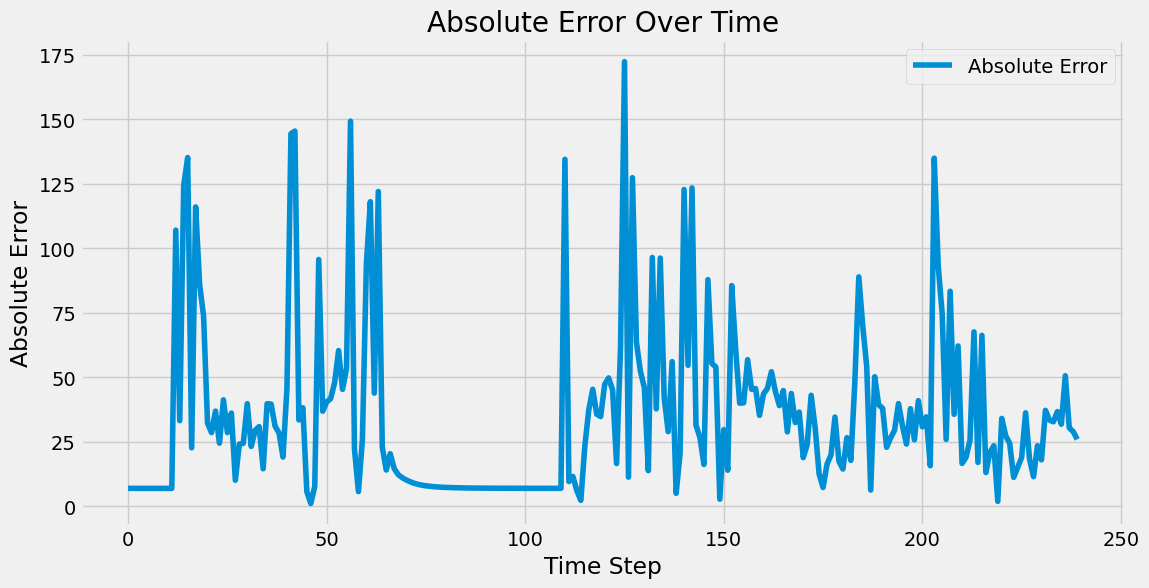

In [87]:
import matplotlib.pyplot as plt

errors = np.abs(test_set2 - predicted_data2)
plt.figure(figsize=(12, 6))
plt.plot(errors, label='Absolute Error')
plt.title('Absolute Error Over Time')
plt.xlabel('Time Step')
plt.ylabel('Absolute Error')
plt.legend()
plt.show()
